In [1]:
%%capture
# Install necessary Python libraries. '%%capture' suppresses the installation output.
# numpy: fundamental package for scientific computing with Python.
# pandas: data manipulation and analysis library, great for tabular data.
# statmodels: for estimating and testing statistical models.
# scipy: for scientific computing and technical computing.
!pip install numpy pandas statmodels scipy

In [2]:
import numpy as np # Import NumPy, a library for numerical operations, aliased as 'np'.
from numpy.random import binomial, multivariate_normal, normal, uniform # Import specific functions for generating random numbers from NumPy's random module.
import pandas as pd # Import Pandas, a library for data manipulation and analysis, aliased as 'pd'.

from random import choices # Import 'choices' for selecting items randomly from a sequence.
from scipy import stats # Import SciPy's stats module for statistical functions.
from statsmodels.api import OLS # Import Ordinary Least Squares (OLS) model from statsmodels for linear regression.
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor # Import ensemble models from scikit-learn for regression tasks.

import matplotlib.pyplot as plt # Import Matplotlib's pyplot module, aliased as 'plt', for creating static, interactive, and animated visualizations in Python.

# Metalearners Estimators

## Abstract

The focus on this notebook will be on the **CATE estimation**.

The CATE (Conditional Average Treatment Effect) generalizes the ATE. We are in the setting of binary treatment $W\in\{0,1\}$, with response variable $Y$ and some covariates $\mathbf{X}=\{X_1, X_2, \cdots, X_n\}$.

Recall the CATE definition:
$$
\tau(\textbf{x}):=\mathbb{E}\left[Y(1)-Y(0)|\mathbf{X}=\mathbf{x}\right]
$$

If $\mathbf{X}$ consists of all observed covariates, we talk about **IATE** (Individualized Average Treatment Effect). In the current notebook we are concerned about CATE estimation, thus we assume from now that the set $\mathbf{X}$ also contains a **sufficient adjustment set**, that is we already achieved the **identification** of the effect.

**Metalearners** are binary treatment CATE estimators. The name *metalearners* stems from being agnostic with respect to the specific model(s) that is used inside them for regression purposes. They differ among each other in the way they exploit data and account for the heterogeneous propensity score of being treated: $P(W=1|\mathbf{X})$.

The methods presented here are:

1. **S-learner**: for COM estimation
2. **T-learner**: for GCOM estimation
3. **X-learner**: improved version of GCOM

The methods will be implemented and evaluated on synthetic data, in both their accuracy and bias variance. Some parts of code are taken from the [EconML](https://github.com/py-why/EconML) example notebooks.

## Data

We use the data generating process from [Kunzel et al.](https://arxiv.org/abs/1706.03461). The outcome $Y$ is generated as a function of the treatment $W$ and $d$ covariates $\mathbf{X}$ by means of the following equation:

$$
Y = \mu_1(\mathbf{x}) \cdot W + \mu_0(\mathbf{x}) \cdot (1-W) + \epsilon
$$

where:
* $\mathbf{X} \sim N(0, \mathbf{\Sigma})$, $~W \sim Bern(e(\mathbf{x}))$ are the distributions of the observed variables
* $e(\mathbf{x}) = P(W=1|\mathbf{X}=\mathbf{x})$ is the propensity score
* $\mu_0(\mathbf{x}) = \mathbf{x}^T\beta$ with $\beta\sim Unif([-3, 3]^d)$
* $\mu_1(\mathbf{x}) = \mu_0(\mathbf{x}) + 8\cdot\mathbf{I}(x_2>0.1)$



The CATE definition is the same as depicted above. With this data generation mechanism, it ends up that the true CATE is:
$$
\mathbf{\tau}(\mathbf{x}) = 8\cdot\mathbf{I}(x_2>0.1)
$$

We implement the data generation mechanism with a custom propensity score $e(\mathbf{x})$ and $\mathbf{\Sigma}=\mathbf{I}$, the identity matrix.

In [3]:
# Define DGP (Data Generating Process) function.
def generate_data(n, d):

    """
    Parameters:
        n (int): population size, representing the number of data points.
        d (int): number of covariates, which are features or independent variables.
    """

    # Generate covariates (features).
    # X is created by sampling from a multivariate normal distribution.
    # np.zeros(d): mean vector of d zeros.
    # np.diag(np.ones(d)): covariance matrix, an identity matrix of size d x d, meaning no correlation between covariates.
    # n: number of samples to generate.
    X = multivariate_normal(np.zeros(d), np.diag(np.ones(d)), n)
    # Create a dictionary of covariates, naming them X_0, X_1, etc.
    X_dict = {f"X_{k}":X[:, k] for k in range(X.shape[1])}

    # Define the propensity function, e(x) = P(W=1|X=x).
    # This function determines the probability of receiving treatment based on covariate X_2.
    # If X_2 is between -0.5 and 0.5, propensity is 0.8; otherwise, it's 0.2.
    propensity = lambda x: (0.8 if (x[2]>-0.5 and x[2]<0.5) else 0.2)

    # Generate treatment assignments (W) based on the propensity score.
    # np.apply_along_axis applies the lambda function to each row of X.
    # binomial(1, p, 1)[0]: generates a single Bernoulli trial (0 or 1) with probability 'p'.
    T = np.apply_along_axis(lambda x: binomial(1, propensity(x), 1)[0], 1, X)

    # Define mu_0, the outcome in the control group (W=0).
    # beta: coefficients for covariates, sampled uniformly between -3 and 3.
    beta = uniform(-3, 3, d)
    # mu_0 is a linear combination of covariates X and beta coefficients (X * beta).
    mu_0 = np.apply_along_axis(lambda x: np.dot(x, beta), 1, X)

    # Define the treatment effect function (tau(x)).
    # The treatment effect is 8 if X_1 > 0.1, otherwise it's 0.
    treatment_effect = lambda x: (1 if x[1] > 0.1 else 0)*8

    # Generate the observed outcome Y.
    # Calculate the true treatment effect for each sample.
    treat_effect = np.apply_along_axis(lambda x: treatment_effect(x), 1, X)
    # Y is generated based on the potential outcomes model: Y = mu_1*W + mu_0*(1-W) + epsilon.
    # Here, treat_effect represents (mu_1 - mu_0).
    # Y = (mu_0 + (mu_1 - mu_0)*W) + noise = treat_effect * T + mu_0 + noise.
    # normal(0, 1): adds random noise from a standard normal distribution.
    Y = treat_effect * T + mu_0 + normal(0, 1)

    # Return a Pandas DataFrame containing 'y' (outcome), 'w' (treatment), 'X_i' (covariates), and 'CATE' (true conditional average treatment effect).
    return pd.DataFrame({"y": Y, "w": T, **X_dict, "CATE": treat_effect})

In [4]:
# Set the number of covariates (d) and the total population size (n).
d = 5
n = 1000

# Generate the complete dataset using the previously defined 'generate_data' function.
data = generate_data(n, d)
# Split the data into training and testing sets.
# 'sample(frac=0.8, random_state=42)' selects 80% of the data randomly for training.
train_data = data.sample(frac=0.8,random_state = 42)
# The remaining 20% of the data is used for testing. 'drop(train_data.index)' removes training rows from the original data.
# 'sort_values(by = "X_1")' sorts the test data by covariate X_1, which might be useful for plotting later.
test_data = data.drop(train_data.index).sort_values(by = "X_1")

# Extract outcome (y), treatment (w), covariates (X), and true CATE for the training set.
# 'iloc[:, 2:-1]' selects all rows and columns from the 3rd to the second-to-last (i.e., all X covariates).
train_y, train_w, train_X, train_true_cate = train_data["y"], train_data["w"], train_data.iloc[:, 2:-1], train_data.iloc[:, -1]
# Extract outcome (y), treatment (w), covariates (X), and true CATE for the testing set.
test_y, test_w, test_X, test_true_cate = test_data["y"], test_data["w"], test_data.iloc[:, 2:-1], test_data.iloc[:, -1]

In [ ]:
train_data.head() # Display the first 5 rows of the 'train_data' DataFrame. This helps in quickly inspecting the structure and content of the training dataset after it has been generated and split.

,y,w,X_0,X_1,X_2,X_3,X_4,CATE
521,3.826211,1,0.653345,-1.619501,-0.463704,0.238187,0.295166,0
737,-3.889430,0,-1.167332,-1.002809,-1.008116,0.563935,1.172347,0
740,2.187243,1,1.028217,-0.778522,0.325408,-0.044973,1.291936,0
660,0.900877,0,-0.136673,-1.111261,0.785260,-0.977085,-1.143490,0
411,-2.592401,0,1.573622,2.419188,0.779216,-0.042372,0.502547,8


## S-learner, T-learner, X-learner

### Implementation

The following implementations are based on the pseudocode available in [Kunzel et al. (2019), pp.40-41](https://arxiv.org/pdf/1706.03461).

In [20]:
class SLearner:

    def __init__(self, model):
      self.model = model # Store the regression model (e.g., GradientBoostingRegressor) that will be used for predictions.

    def fit(self, X: pd.DataFrame, y: pd.DataFrame, w: pd.DataFrame):
        # Concatenate the covariates (X) and treatment assignments (w) to form the input features for the S-learner.
        # The S-learner builds a single model to predict the outcome based on both features and treatment.
        # Convert to .values to ensure consistent numpy array input to the sklearn model, avoiding UserWarning regarding feature names.
        self.mu = self.model().fit(pd.concat([X, w], axis = 1).values, y.values) # Fit the chosen model (e.g., GradientBoostingRegressor) to predict 'y' using 'X' and 'w'.
        return self # Return the fitted S-Learner object.

    def predict(self, X: pd.DataFrame) -> pd.DataFrame:
        # Create two sets of treatment assignments: one where all individuals receive treatment (w=1).
        w_1 = np.ones((len(X), 1))
        # And another where all individuals receive no treatment (w=0).
        w_0 = np.zeros((len(X), 1))

        # Predict potential outcomes for both scenarios:
        # 1. Outcome if all individuals were treated (Y(1)), using the fitted model with X and w=1.
        # 2. Outcome if all individuals were untreated (Y(0)), using the fitted model with X and w=0.
        # Convert X to .values before concatenating to ensure consistent numpy array input, avoiding UserWarning.
        tau_hat =  self.mu.predict(np.concatenate((X.values, w_1), axis = 1)) - self.mu.predict(np.concatenate((X.values, w_0), axis = 1))
        return pd.DataFrame(tau_hat, columns = ["tau"]) # Return the estimated CATE as a Pandas DataFrame.

In [21]:
class TLearner:

    def __init__(self, model):
      self.model = model # Store the regression model that will be used for predictions.

    def fit(self, X: pd.DataFrame, y: pd.DataFrame, w: pd.DataFrame):
        # Create boolean masks to separate the data into treated (w=1) and control (w=0) groups.
        I0, I1 = (w == 0), (w == 1) # I0 for control group, I1 for treated group.
        # Subset the dataset based on treatment assignment.
        X0, y0, X1, y1 = X[I0], y[I0], X[I1], y[I1] # X0, y0 are covariates and outcomes for control; X1, y1 for treated.
        # Fit a separate model (mu_0) for the control group to predict outcome (y0) using only covariates (X0).
        # Convert to .values to ensure consistent numpy array input to the sklearn model, avoiding UserWarning.
        self.mu_0 = self.model().fit(X0.values, y0.values) # Estimator for Y0 ~ X0.
        # Fit another separate model (mu_1) for the treated group to predict outcome (y1) using only covariates (X1).
        # Convert to .values to ensure consistent numpy array input to the sklearn model, avoiding UserWarning.
        self.mu_1 = self.model().fit(X1.values, y1.values) # Estimator for Y1 ~ X1.

        return self # Return the fitted T-Learner object.

    def predict(self, X: pd.DataFrame) -> pd.DataFrame:
        # Predict potential outcomes for each individual in X using the two fitted models:
        # 1. Predict Y(1) using the model trained on the treated group (mu_1).
        # 2. Predict Y(0) using the model trained on the control group (mu_0).
        # Convert X to .values to ensure consistent numpy array input, avoiding UserWarning.
        # Compute the CATE by taking the difference between the predicted treated outcome and the predicted control outcome.
        tau_hat =  self.mu_1.predict(X.values) - self.mu_0.predict(X.values) # Compute the CATE.

        return pd.DataFrame(tau_hat, columns = ["tau"]) # Return the estimated CATE as a Pandas DataFrame.

In [22]:
class XLearner:

    def __init__(self, model, propensity_model):
      self.model = model # Store the base regression model for outcome prediction.
      self.propensity_model = propensity_model # Store the model for estimating the propensity score (P(W=1|X)).

    def fit(self, X: pd.DataFrame, y: pd.DataFrame, w: pd.DataFrame):
        # Step 1: Estimate the propensity score.
        # Fit a model to predict the treatment assignment (w) based on covariates (X).
        # Convert to .values to ensure consistent numpy array input to the sklearn model, avoiding UserWarning.
        self.g = self.propensity_model().fit(X.values, w.values) # Fit the propensity score estimator.

        # Step 2: Split data and train outcome models (same as T-learner).
        I0, I1 = (w == 0), (w == 1) # Create boolean masks for control (I0) and treated (I1) groups.
        X0, y0, X1, y1 = X[I0], y[I0], X[I1], y[I1] # Subset the data for control and treated groups.
        # Convert to .values to ensure consistent numpy array input to the sklearn model, avoiding UserWarning.
        self.mu_0 = self.model().fit(X0.values, y0.values) # Fit outcome model for the control group.
        # Convert to .values to ensure consistent numpy array input to the sklearn model, avoiding UserWarning.
        self.mu_1 = self.model().fit(X1.values, y1.values) # Fit outcome model for the treated group.

        # Step 3: Impute treatment effects for the 'opposite' group.
        # For control individuals (X0), estimate what their outcome *would have been* if they were treated (mu_1.predict(X0)).
        # Then, calculate the 'imputed treatment effect' for the control group: Y(1) - Y(0) = predicted_treated_outcome - actual_control_outcome.
        # Convert to .values to ensure consistent numpy array input, avoiding UserWarning.
        D0 = self.mu_1.predict(X0.values) - y0.values # Compute the treatment effects for control group based on treated outcome model.
        # For treated individuals (X1), estimate what their outcome *would have been* if they were untreated (mu_0.predict(X1)).
        # Then, calculate the 'imputed treatment effect' for the treated group: Y(1) - Y(0) = actual_treated_outcome - predicted_control_outcome.
        # Convert to .values to ensure consistent numpy array input, avoiding UserWarning.
        D1 = y1.values - self.mu_0.predict(X1.values) # Compute the treatment effects for treated group based on control outcome model.

        # Step 4: Train two CATE models.
        # Fit a model (tau_0) to predict the imputed treatment effects (D0) using covariates (X0) from the control group.
        # Convert to .values to ensure consistent numpy array input to the sklearn model, avoiding UserWarning.
        self.tau_0 = self.model().fit(X0.values, D0) # Estimate CATE from the perspective of the control group.
        # Fit another model (tau_1) to predict the imputed treatment effects (D1) using covariates (X1) from the treated group.
        # Convert to .values to ensure consistent numpy array input to the sklearn model, avoiding UserWarning.
        self.tau_1 = self.model().fit(X1.values, D1) # Estimate CATE from the perspective of the treated group.

        return self # Return the fitted X-Learner object.

    def predict(self, X: pd.DataFrame) -> pd.DataFrame:
        # Step 5: Estimate the propensity score for the prediction data.
        # Convert to .values to ensure consistent numpy array input to the sklearn model, avoiding UserWarning.
        g_hat = self.g.predict(X.values) # Estimate the propensity score P(W=1|X) for new data X.

        # Step 6: Combine the two CATE estimates using the propensity score as a weighted average.
        # The CATE is estimated as a weighted average of tau_0 (from control perspective) and tau_1 (from treated perspective).
        # Weights are based on the propensity score: higher propensity (more likely to be treated) gives more weight to tau_1, and vice-versa.
        # Convert to .values to ensure consistent numpy array input, avoiding UserWarning.
        tau_hat =  g_hat * self.tau_0.predict(X.values) + (1 - g_hat) * self.tau_1.predict(X.values) # Average the estimates.

        return pd.DataFrame(tau_hat, columns = ["tau"]) # Return the final estimated CATE as a Pandas DataFrame.

### Evaluation

We set a **model** for regressing $Y$ and a model for the propensity score. Notice that, by using a model for $e(\mathbf{x})$ in the X-learner, we are estimating the CATE in a **doubly-robust** fashion, as indeed suggested by Kunzel et al.

In [8]:
# Choose models
# Assign GradientBoostingRegressor to 'model'. This will be the base regression model used within the metalearners.
model = GradientBoostingRegressor
# Assign RandomForestRegressor to 'propensity_model'. This will be used specifically by the X-Learner to estimate propensity scores.
propensity_model = RandomForestRegressor

# Re-assign the true CATE values for the training set to a new variable. This is used for comparison with predictions.
train_true_cate = train_data["CATE"]
# Re-assign the true CATE values for the test set to a new variable. This is crucial for evaluating the model's performance on unseen data.
test_true_cate = test_data["CATE"]

In [9]:
# Create an instance of the SLearner class, passing the chosen 'model' (GradientBoostingRegressor).
# Then, immediately call the 'fit' method, providing the training data (covariates train_X, outcomes train_y, and treatment assignments train_w).
# This trains the S-learner to learn the relationship between (X, W) and Y.
s_learner = SLearner(model).fit(train_X, train_y, train_w)

In [10]:
# Use the fitted S-learner to predict the CATE for the training set. This shows how well the model learned on data it has seen.
train_pred_cate_s = s_learner.predict(train_X)
# Use the fitted S-learner to predict the CATE for the test set. This evaluates the model's generalization ability on unseen data.
test_pred_cate_s = s_learner.predict(test_X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [11]:
# Create an instance of the TLearner class, passing the chosen 'model' (GradientBoostingRegressor).
# Then, immediately call the 'fit' method with the training data (covariates train_X, outcomes train_y, and treatment assignments train_w).
# The T-learner trains two separate models: one for the treated group and one for the control group.
t_learner = TLearner(model).fit(train_X, train_y, train_w)

In [12]:
# Use the fitted T-learner to predict the CATE for the training set. This checks its performance on known data.
train_pred_cate_t = t_learner.predict(train_X)
# Use the fitted T-learner to predict the CATE for the test set. This evaluates its ability to predict CATE on new data.
test_pred_cate_t = t_learner.predict(test_X)

In [13]:
# Create an instance of the XLearner class, passing both the main 'model' and the 'propensity_model'.
# Then, immediately call the 'fit' method with the training data (train_X, train_y, train_w).
# The X-learner is more complex, involving propensity score estimation, two outcome models, and two CATE models.
x_learner = XLearner(model, propensity_model).fit(train_X, train_y, train_w)

In [14]:
# Use the fitted X-learner to predict the CATE for the training set.
train_pred_cate_x = x_learner.predict(train_X)
# Use the fitted X-learner to predict the CATE for the test set.
test_pred_cate_x = x_learner.predict(test_X)

We compare these three metalearners in their point-wise accuracy and bias variance.

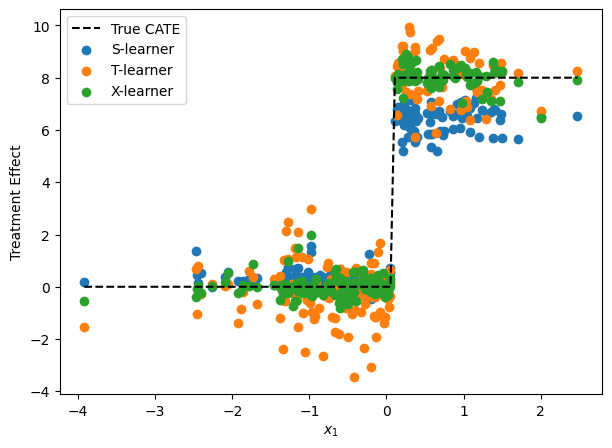

In [15]:
plt.figure(figsize=(7, 5)) # Create a new figure for plotting with a specified width and height.
plt.plot(test_X.iloc[:, 1], test_true_cate, color='black', ls='--', label='True CATE') # Plot the true CATE values from the test set against the second covariate (X_1). This serves as a baseline.
plt.scatter(test_X.iloc[:, 1], test_pred_cate_s, label="S-learner") # Plot the CATE predictions from the S-learner against X_1, using scatter points.
plt.scatter(test_X.iloc[:, 1], test_pred_cate_t, label="T-learner") # Plot the CATE predictions from the T-learner against X_1.
plt.scatter(test_X.iloc[:, 1], test_pred_cate_x, label="X-learner") # Plot the CATE predictions from the X-learner against X_1.
plt.xlabel('$x_1$') # Label the x-axis as '$x_1$', representing the covariate.
plt.ylabel('Treatment Effect') # Label the y-axis as 'Treatment Effect', representing the CATE values.
plt.legend() # Display the legend to identify which points correspond to which learner or the true CATE.
plt.show() # Display the generated plot.

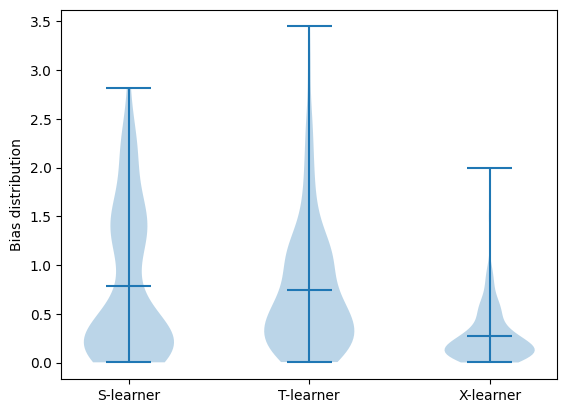

In [16]:
# Visualization of bias distribution
# Create a violin plot to visualize the distribution of absolute bias (difference between predicted and true CATE) for each learner.
# np.abs(... - ...): Calculates the absolute difference between the predicted CATE and the true CATE for each learner.
# .values[:,0]: Converts the Pandas DataFrame/Series to a NumPy array and selects the first column (the CATE estimates).
plt.violinplot([np.abs(test_pred_cate_s.values[:,0] - test_true_cate),
                np.abs(test_pred_cate_t.values[:,0] - test_true_cate),
                np.abs(test_pred_cate_x.values[:,0] - test_true_cate)],
               showmeans=True) # showmeans=True adds a marker for the mean of each distribution.
plt.ylabel("Bias distribution") # Label the y-axis to indicate that it shows the bias distribution.
plt.xticks([1, 2, 3], ['S-learner', 'T-learner', 'X-learner']) # Set custom x-axis tick labels for each violin plot (1, 2, 3 correspond to S, T, X learners).
plt.show() # Display the violin plot.

### Confidence intervals

Following Kunzel et al., we may also want to give the estimate a confidence interval. This is performed in a bootstrapping fashion. We choose to compute the interval for the first test set record, using the Xlearning procedure.

In [24]:
def compute_ci(
    X: pd.DataFrame,
    y: pd.DataFrame,
    w: pd.DataFrame,
    p: pd.DataFrame,
    B: int,
    alpha: float
):
    # Get indices stratified on treatment.
    # Get the indices of samples where treatment (w) is 0 (control group).
    S0, S1 = w.index[w == 0].tolist(), w.index[w == 1].tolist()
    # Get numbers of samples per strata.
    # Get the number of samples in the control group (n0) and treated group (n1).
    n0, n1 = len(S0), len(S1)
    # List of bootstrap estimates.
    # Initialize an empty list to store the CATE estimates from each bootstrap sample.
    tau_hat_b = []
    # Perform the bootstrap.
    # Loop 'B' times to create 'B' bootstrap samples.
    for b in range(B):
        # Resample dataset with replacement.
        # Randomly sample 'n0' indices from the control group (S0) with replacement, and 'n1' indices from the treated group (S1) with replacement.
        # This creates a new bootstrap sample 's_b' maintaining the original treatment proportions.
        s_b = choices(S0, k = n0) + choices(S1, k = n1)
        # Subset the original data (X, y, w) using the bootstrap sample indices 's_b'.
        X_b, y_b, w_b = X.loc[s_b, :], y.loc[s_b], w.loc[s_b]
        # Fit the X-Learner estimator on the current bootstrap sample and predict the CATE for the specific point 'p'.
        # The result is appended to the list 'tau_hat_b'.
        tau_hat_b.append(XLearner(model, propensity_model).fit(X_b, y_b, w_b).predict(p))
    # Fit the estimator on the data set.
    # Fit the X-Learner once on the original full dataset (X, y, w) to get the point estimate of CATE for 'p'.
    tau_hat = XLearner(model, propensity_model).fit(X, y, w).predict(p)
    # Compute the standard deviation of the boostrap estimates.
    # Convert the list of CATE estimates from bootstrap samples into a single DataFrame and calculate its standard deviation.
    sigma = np.std(pd.concat(tau_hat_b), axis=0) # Added axis=0 to suppress FutureWarning
    # Compute the confidence interval with the given signficance level alpha.
    # Use the normal distribution to calculate the lower and upper bounds of the confidence interval.
    # '1 - alpha' is the confidence level (e.g., 0.95 for alpha=0.05).
    # 'loc' is the mean (our point estimate tau_hat), 'scale' is the standard deviation (sigma).
    lower, upper = stats.norm.interval(1 - alpha, loc = tau_hat.values[0], scale = sigma[0]) # Modified to extract scalar values to suppress DeprecationWarning

    # Return the point estimate of CATE and the calculated confidence interval (lower, upper).
    return (float(tau_hat.values[0]), (float(lower), float(upper))) # Modified to extract scalar values to suppress DeprecationWarning

In [23]:
# This is a Jupyter magic command that measures the execution time of the cell.
%%time
# Call the 'compute_ci' function to calculate the confidence interval for a specific test data point.
compute_ci(
    X = train_X, # Pass the training covariates.
    y = train_y, # Pass the training outcomes.
    w = train_w, # Pass the training treatment assignments.
    p = test_data.iloc[[0], 2:-1], # Pass the first row of the test covariates (X) as the point 'p' for which to compute the CI.
    B = 100, # Set the number of bootstrap samples to 100.
    alpha = 0.05 # Set the significance level (alpha) to 0.05, corresponding to a 95% confidence interval.
)

CPU times: user 1min 49s, sys: 222 ms, total: 1min 49s
Wall time: 1min 51s


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/tmp/ipykernel_979/2702495468.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return (float(tau_hat.to_numpy()), (float(lower), float(upper)))


(-0.6322391455491261, (-1.6456919858663477, 0.3812136947680955))

## Additional material

The [EconML](https://github.com/py-why/EconML) package provides the same, plus others, pre-built metalearners, such as the DomainAdaptation-Learner.

1. [Here](https://github.com/py-why/EconML/blob/main/notebooks/Metalearners%20Examples.ipynb) you can find a comprehensive notebook on how to use them and compare the predictions
2. Another useful notebook, to be kept as a reference, is the one regarding [Double Machine Learning](https://github.com/py-why/EconML/blob/main/notebooks/Double%20Machine%20Learning%20Examples.ipynb) algorithms.